In [ ]:
import pandas as pd
df_labeled = pd.read_csv('Comment Annotations  - sample_for_annotating.csv')

## Rename and transform df labeled

In [ ]:
df_labeled = df_labeled.rename(columns={'ID': 'Ref.', 'Stance': 'labeled_stance'})
df_labeled['labeled_stance'] = df_labeled['labeled_stance'].replace({1: 'support', 2: 'against', 3: 'uncertain'})
df_labeled.loc[df_labeled['Exemption (Yes = 1, No = 0)'] == 1, 'labeled_stance'] = 'exemption'
df_labeled.head()

,Ref.,Date,Org. type,Org. name,Country,Company name confidential,Attachment,Privacy statement,General Comments,Answer to specific info request 2,...,Combined Comments,annotator,NACE code,labeled_stance,Argument type(s),"Exemption (Yes = 1, No = 0)",Not enough info,Unnamed: 44,Unnamed: 45,Unnamed: 46
0,5057,2023/06/22 12:25,NaN,NaN,Sweden,No,NaN,NaN,It's important to stop the use of dangerous ch...,NaN,...,General comments: It's important to stop the u...,Marko,NaN,support,5,0,0.0,NaN,Type of Argument,Premise
1,6661,2023/08/11 11:49,Company,<redacted>,Spain,Yes,NaN,NaN,The restriction of PFAS substances for industr...,NaN,...,General comments: The restriction of PFAS subs...,Marko,Unclear,exemption,"3, 3.1, 4.",1,0.0,NaN,1. Scientific,1.1. Polymer of low concern (PLC)
2,6927,2023/08/23 10:27,Company,"Shandong Dongyue Polymer Materials Co., Ltd",China,No,NaN,NaN,"First, polytetrafluoroethylene can not be repl...",NaN,...,"General comments: First, polytetrafluoroethyle...",Marko,C,exemption,"2, 2.3",1,0.0,NaN,NaN,1.2. The chemical is not toxic
3,6396,2023/07/31 17:22,Company,W. L. Gore & Associates GmbH,Germany,No,NaN,As disclosure would undermine the protection o...,We provide information in the attachments. 6396,NaN,...,General comments: We provide information in th...,Marko,C26,exemption,5,1,1.0,NaN,NaN,1.3. Waste can be managed
4,5243,2023/06/22 14:36,NaN,NaN,Sweden,No,NaN,NaN,We can’t eat the fish from our closest lake Mä...,NaN,...,General comments: We can’t eat the fish from o...,Marko,NaN,support,5,0,0.0,NaN,NaN,1.4. Emissions can be managed


## Load df prediction

In [ ]:
df_prediction = pd.read_csv('df_final_complete.csv')
df_prediction.head()

,Ref.,Type,Date,Content,Org. country,Org. type,Org. name,Company name confidential,attachment_author,General Comments,...,attachments,combined_text,attachment_link_dummy,confidential_info_dummy,missing_key_info,fine_sector,stance_T0_2,stance_T0_5,stance_T0_7,gpt_stance
0,3843,Individual,3/22/2023 18:20,Scope or restriction option analysis,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,scope of restriction:\nthe proposed restrictio...,0,0,0,C20,uncertain,uncertain,uncertain,against_exemption
1,3849,BehalfOfAnOrganisation,3/23/2023 1:45,Scope or restriction option analysis,Denmark,Company,<redacted>,Yes,SUOMELA Sanna,Please refer to the further outline in the att...,...,https://www.industrydocuments.ucsf.edu/chemica...,please refer to the further outline in the att...,1,0,0,J63,uncertain,uncertain,uncertain,uncertain
2,3851,BehalfOfAnOrganisation,3/23/2023 9:57,Request for exemption,Austria,Company,<redacted>,Yes,NaN,We are using fluoropolymers for seals 3851,...,NaN,we are using fluoropolymers for seals petroleu...,0,0,0,C19,exemption,uncertain,uncertain,uncertain
3,3852,Individual,3/23/2023 10:31,Scope or restriction option analysis,NaN,NaN,NaN,NaN,NaN,The proposed ban encompasses an inconceivable ...,...,NaN,the proposed ban encompasses an inconceivable ...,0,0,0,C21,uncertain,uncertain,uncertain,against
4,3853,BehalfOfAnOrganisation,3/24/2023 10:30,Scope or restriction option analysis,Germany,Company,ESZ W. Becker GmbH,NaN,NaN,"Good morning, We are a manufacturer of elastom...",...,NaN,"good morning,\nwe are a manufacturer of elasto...",0,0,0,C22,uncertain,uncertain,uncertain,against


## Rename and transform df prediction


In [ ]:
df_prediction = df_prediction.rename(columns={'stance_T0_2': 'bart_stance'})
df_prediction['gpt_stance'] = df_prediction['gpt_stance'].replace({'support_exemption': 'exemption', 'against_exemption': 'exemption'})
df_prediction.head()

,Ref.,Type,Date,Content,Org. country,Org. type,Org. name,Company name confidential,attachment_author,General Comments,...,attachments,combined_text,attachment_link_dummy,confidential_info_dummy,missing_key_info,fine_sector,bart_stance,stance_T0_5,stance_T0_7,gpt_stance
0,3843,Individual,3/22/2023 18:20,Scope or restriction option analysis,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,scope of restriction:\nthe proposed restrictio...,0,0,0,C20,uncertain,uncertain,uncertain,exemption
1,3849,BehalfOfAnOrganisation,3/23/2023 1:45,Scope or restriction option analysis,Denmark,Company,<redacted>,Yes,SUOMELA Sanna,Please refer to the further outline in the att...,...,https://www.industrydocuments.ucsf.edu/chemica...,please refer to the further outline in the att...,1,0,0,J63,uncertain,uncertain,uncertain,uncertain
2,3851,BehalfOfAnOrganisation,3/23/2023 9:57,Request for exemption,Austria,Company,<redacted>,Yes,NaN,We are using fluoropolymers for seals 3851,...,NaN,we are using fluoropolymers for seals petroleu...,0,0,0,C19,exemption,uncertain,uncertain,uncertain
3,3852,Individual,3/23/2023 10:31,Scope or restriction option analysis,NaN,NaN,NaN,NaN,NaN,The proposed ban encompasses an inconceivable ...,...,NaN,the proposed ban encompasses an inconceivable ...,0,0,0,C21,uncertain,uncertain,uncertain,against
4,3853,BehalfOfAnOrganisation,3/24/2023 10:30,Scope or restriction option analysis,Germany,Company,ESZ W. Becker GmbH,NaN,NaN,"Good morning, We are a manufacturer of elastom...",...,NaN,"good morning,\nwe are a manufacturer of elasto...",0,0,0,C22,uncertain,uncertain,uncertain,against


## Merge dataframes

In [ ]:
df_merged = pd.merge(df_labeled, df_prediction, on='Ref.', how='inner')
df_merged.head()

,Ref.,Date_x,Org. type_x,Org. name_x,Country,Company name confidential_x,Attachment,Privacy statement,General Comments_x,Answer to specific info request 2,...,attachments,combined_text,attachment_link_dummy_y,confidential_info_dummy_y,missing_key_info_y,fine_sector,bart_stance,stance_T0_5,stance_T0_7,gpt_stance
0,5057,2023/06/22 12:25,NaN,NaN,Sweden,No,NaN,NaN,It's important to stop the use of dangerous ch...,NaN,...,NaN,it's important to stop the use of dangerous ch...,0,0,0,C20,uncertain,uncertain,uncertain,support
1,6927,2023/08/23 10:27,Company,"Shandong Dongyue Polymer Materials Co., Ltd",China,No,NaN,NaN,"First, polytetrafluoroethylene can not be repl...",NaN,...,https://www.industrydocuments.ucsf.edu/chemica...,"first, polytetrafluoroethylene can not be repl...",1,0,0,C,uncertain,uncertain,uncertain,against
2,6396,2023/07/31 17:22,Company,W. L. Gore & Associates GmbH,Germany,No,NaN,As disclosure would undermine the protection o...,We provide information in the attachments. 6396,NaN,...,NaN,we provide information in the attachments. sem...,0,0,0,C26,uncertain,uncertain,uncertain,uncertain
3,5243,2023/06/22 14:36,NaN,NaN,Sweden,No,NaN,NaN,We can’t eat the fish from our closest lake Mä...,NaN,...,NaN,we can’t eat the fish from our closest lake mä...,0,0,0,E38,uncertain,uncertain,uncertain,support
4,6937,2023/08/23 11:02,Company,<redacted>,"Korea, Republic of",Yes,<redacted>,Contains business data,"First, we endorse FCJ's statement on the issue...",NaN,...,https://www.industrydocuments.ucsf.edu/chemica...,"first, we endorse fcj's statement on the issue...",1,0,0,C19,uncertain,uncertain,uncertain,exemption


## Prepare for evaluation

In [ ]:
df_eval = df_merged[['Ref.', 'labeled_stance', 'bart_stance', 'gpt_stance']]
df_eval = df_eval.dropna(subset=['labeled_stance', 'bart_stance', 'gpt_stance'])
display(df_eval.head())
display(df_eval.shape)

,Ref.,labeled_stance,bart_stance,gpt_stance
0,5057,support,uncertain,support
1,6927,exemption,uncertain,against
2,6396,exemption,uncertain,uncertain
3,5243,support,uncertain,support
4,6937,exemption,uncertain,exemption


(226, 4)

## Evaluation metrics


In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

stance_labels = sorted(list(df_eval['labeled_stance'].unique()) +
                       list(df_eval['bart_stance'].unique()) +
                       list(df_eval['gpt_stance'].unique()))

cm_bart = confusion_matrix(df_eval['labeled_stance'], df_eval['bart_stance'], labels=stance_labels)
cm_gpt = confusion_matrix(df_eval['labeled_stance'], df_eval['gpt_stance'], labels=stance_labels)

precision_bart = precision_score(df_eval['labeled_stance'], df_eval['bart_stance'], labels=stance_labels, average='weighted')
recall_bart = recall_score(df_eval['labeled_stance'], df_eval['bart_stance'], labels=stance_labels, average='weighted')
f1_bart = f1_score(df_eval['labeled_stance'], df_eval['bart_stance'], labels=stance_labels, average='weighted')

precision_gpt = precision_score(df_eval['labeled_stance'], df_eval['gpt_stance'], labels=stance_labels, average='weighted')
recall_gpt = recall_score(df_eval['labeled_stance'], df_eval['gpt_stance'], labels=stance_labels, average='weighted')
f1_gpt = f1_score(df_eval['labeled_stance'], df_eval['gpt_stance'], labels=stance_labels, average='weighted')

print("Confusion Matrix for Bart Stance vs Labeled Stance:\n", cm_bart)
print("\nConfusion Matrix for GPT Stance vs Labeled Stance:\n", cm_gpt)
print(f"\nBart Stance - Precision: {precision_bart:.4f}, Recall: {recall_bart:.4f}, F1-score: {f1_bart:.4f}")
print(f"GPT Stance - Precision: {precision_gpt:.4f}, Recall: {recall_gpt:.4f}, F1-score: {f1_gpt:.4f}")

Confusion Matrix for Bart Stance vs Labeled Stance:
 [[ 0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  3  0  0  3  0  0 17]
 [ 0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  4  0  0 26  0  0 20  0  0 46]
 [ 0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  4  0  0 13  0  0 54]
 [ 0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  9  0  0  6  0  0 21]]

Confusion Matrix for GPT Stance vs Labeled Stance:
 [[ 0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 11  0  0  6  0  0  2  0  0  4]
 [ 0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 27  0  0 56  0  0  3  0  0 10]
 [ 0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  1  0  0 69  0  0  1]
 [ 0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 

## Summarize Evaluation Results


In [ ]:
import pandas as pd

metrics_data = {
    'Metric': ['Precision', 'Recall', 'F1-score'],
    'Bart Stance': [precision_bart, recall_bart, f1_bart],
    'GPT Stance': [precision_gpt, recall_gpt, f1_gpt]
}

df_metrics = pd.DataFrame(metrics_data)
display(df_metrics)

,Metric,Bart Stance,GPT Stance
0,Precision,0.384438,0.761950
1,Recall,0.265487,0.716814
2,F1-score,0.270796,0.725951


In [ ]:
from sklearn.metrics import accuracy_score
import pandas as pd

# Calculate accuracy
accuracy_bart = accuracy_score(df_eval['labeled_stance'], df_eval['bart_stance'])
accuracy_gpt = accuracy_score(df_eval['labeled_stance'], df_eval['gpt_stance'])

# Your data
metrics_data = {
    'Model': ['Bart Stance', 'GPT Stance'],
    'Accuracy': [accuracy_bart, accuracy_gpt],
    'F1 score': [f1_bart, f1_gpt],
    'Precision': [precision_bart, precision_gpt],
    'Recall': [recall_bart, recall_gpt]
}

# Create DataFrame
df_metrics = pd.DataFrame(metrics_data)

# Format the numbers as percentages with 2 decimal places
for col in ['Accuracy', 'F1 score', 'Precision', 'Recall']:
    df_metrics[col] = df_metrics[col].apply(lambda x: f"{x*100:.2f}%")

# Display the table
display(df_metrics)

,Model,Accuracy,F1 score,Precision,Recall
0,Bart Stance,26.55%,27.08%,38.44%,26.55%
1,GPT Stance,71.68%,72.60%,76.20%,71.68%


# Per-Stance Evaluation Metrics

In [ ]:
# Cell 12: Per-Stance Evaluation Metrics (Building on existing code)
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def calculate_per_stance_metrics():
    """Calculate precision, recall, accuracy, and F1 score for each stance type"""

    # Use the existing df_eval from previous cells
    print(f"Using existing df_eval with {len(df_eval)} rows")
    print(f"Available stances: {sorted(df_eval['labeled_stance'].unique())}")

    # Define stance types
    stance_types = ['support', 'against', 'exemption']

    # Create evaluation results
    evaluation_results = []

    # For each stance type, calculate metrics
    for stance_type in stance_types:
        print(f"\nEvaluating {stance_type} stance...")

        for model in ['bart_stance', 'gpt_stance']:
            # Create binary classification for this stance type
            y_true = (df_eval['labeled_stance'] == stance_type).astype(int)
            y_pred = (df_eval[model] == stance_type).astype(int)

            # Calculate metrics
            accuracy = accuracy_score(y_true, y_pred)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            precision = precision_score(y_true, y_pred, zero_division=0)
            recall = recall_score(y_true, y_pred, zero_division=0)

            # Count samples
            true_positives = sum(y_true & y_pred)
            false_positives = sum(~y_true & y_pred)
            false_negatives = sum(y_true & ~y_pred)
            true_negatives = sum(~y_true & ~y_pred)

            print(f"  {model}: TP={true_positives}, FP={false_positives}, FN={false_negatives}, TN={true_negatives}")

            evaluation_results.append({
                'Model': model.replace('_stance', ''),
                'Stance_Type': stance_type,
                'Accuracy': accuracy,
                'F1_Score': f1,
                'Precision': precision,
                'Recall': recall,
                'True_Positives': true_positives,
                'False_Positives': false_positives,
                'False_Negatives': false_negatives,
                'True_Negatives': true_negatives,
                'Sample_Size': len(y_true[y_true == 1]),
                'Total_Samples': len(y_true)
            })

    # Create DataFrame
    eval_df = pd.DataFrame(evaluation_results)

    # Display results in three separate sections
    print("\n" + "="*80)
    print("OVERALL EVALUATION RESULTS")
    print("="*80)
    print(eval_df.round(4).to_string(index=False))

    print("\n" + "="*80)
    print("BART MODEL RESULTS")
    print("="*80)
    bart_results = eval_df[eval_df['Model'] == 'bart'].copy()
    bart_results = bart_results.drop('Model', axis=1)
    print(bart_results.round(4).to_string(index=False))

    print("\n" + "="*80)
    print("GPT MODEL RESULTS")
    print("="*80)
    gpt_results = eval_df[eval_df['Model'] == 'gpt'].copy()
    gpt_results = gpt_results.drop('Model', axis=1)
    print(gpt_results.round(4).to_string(index=False))

    # Create summary comparison
    summary_data = []
    for metric in ['Accuracy', 'F1_Score', 'Precision', 'Recall']:
        for stance_type in stance_types:
            bart_val = bart_results[bart_results['Stance_Type'] == stance_type][metric].iloc[0]
            gpt_val = gpt_results[gpt_results['Stance_Type'] == stance_type][metric].iloc[0]
            summary_data.append({
                'Metric': metric,
                'Stance_Type': stance_type,
                'BART': bart_val,
                'GPT': gpt_val,
                'Difference': gpt_val - bart_val
            })

    summary_df = pd.DataFrame(summary_data)

    print("\n" + "="*80)
    print("SUMMARY COMPARISON")
    print("="*80)
    print(summary_df.round(4).to_string(index=False))

    return eval_df, bart_results, gpt_results, summary_df

# Run the evaluation using existing data
per_stance_results, bart_per_stance, gpt_per_stance, summary_per_stance = calculate_per_stance_metrics()

Using existing df_eval with 226 rows
Available stances: ['against', 'exemption', 'support', 'uncertain']

Evaluating support stance...
  bart_stance: TP=13, FP=29, FN=58, TN=-326
  gpt_stance: TP=69, FP=9, FN=2, TN=-306

Evaluating against stance...
  bart_stance: TP=0, FP=4, FN=23, TN=-253
  gpt_stance: TP=11, FP=29, FN=12, TN=-278

Evaluating exemption stance...
  bart_stance: TP=26, FP=16, FN=70, TN=-338
  gpt_stance: TP=56, FP=11, FN=40, TN=-333

OVERALL EVALUATION RESULTS
Model Stance_Type  Accuracy  F1_Score  Precision  Recall  True_Positives  False_Positives  False_Negatives  True_Negatives  Sample_Size  Total_Samples
 bart     support    0.6150    0.2301     0.3095  0.1831              13               29               58            -326           71            226
  gpt     support    0.9513    0.9262     0.8846  0.9718              69                9                2            -306           71            226
 bart     against    0.8805    0.0000     0.0000  0.0000         

In [ ]:
df_stance_sector = df_final[['fine_sector', 'gpt_stance']]
df_stance_sector = df_stance_sector.dropna(subset=['fine_sector', 'gpt_stance'])
display(df_stance_sector.head())

NameError: name 'df_final' is not defined

## Filter by stance


In [ ]:
df_support = df_stance_sector[df_stance_sector['gpt_stance'] == 'support'].copy()
df_against = df_stance_sector[df_stance_sector['gpt_stance'] == 'against'].copy()
df_exemption = df_stance_sector[df_stance_sector['gpt_stance'] == 'exemption'].copy()

display(df_support.head())
display(df_against.head())
display(df_exemption.head())

,fine_sector,gpt_stance
26,individual,support
58,C20,support
64,individual,support
65,C20,support
121,S94,support


,fine_sector,gpt_stance
3,individual,against
4,C22,against
7,individual,against
8,T,against
12,C20,against


,fine_sector,gpt_stance
0,individual,exemption
6,individual,exemption
9,C20,exemption
10,C20,exemption
14,C20,exemption


## Identify top sectors


In [ ]:
top_sectors_support = df_support['fine_sector'].value_counts().head(3)
top_sectors_against = df_against['fine_sector'].value_counts().head(3)
top_sectors_exemption = df_exemption['fine_sector'].value_counts().head(3)

print("Top 3 Sectors for Support Stance:")
display(top_sectors_support)
print("\nTop 3 Sectors for Against Stance:")
display(top_sectors_against)
print("\nTop 3 Sectors for Exemption Stance:")
display(top_sectors_exemption)

Top 3 Sectors for Support Stance:


,count
fine_sector,
individual,1121
C20,76
M74,61



Top 3 Sectors for Against Stance:


,count
fine_sector,
C20,235
C28,133
C26,130



Top 3 Sectors for Exemption Stance:


,count
fine_sector,
C20,347
C26,247
C28,188


## Visualizations



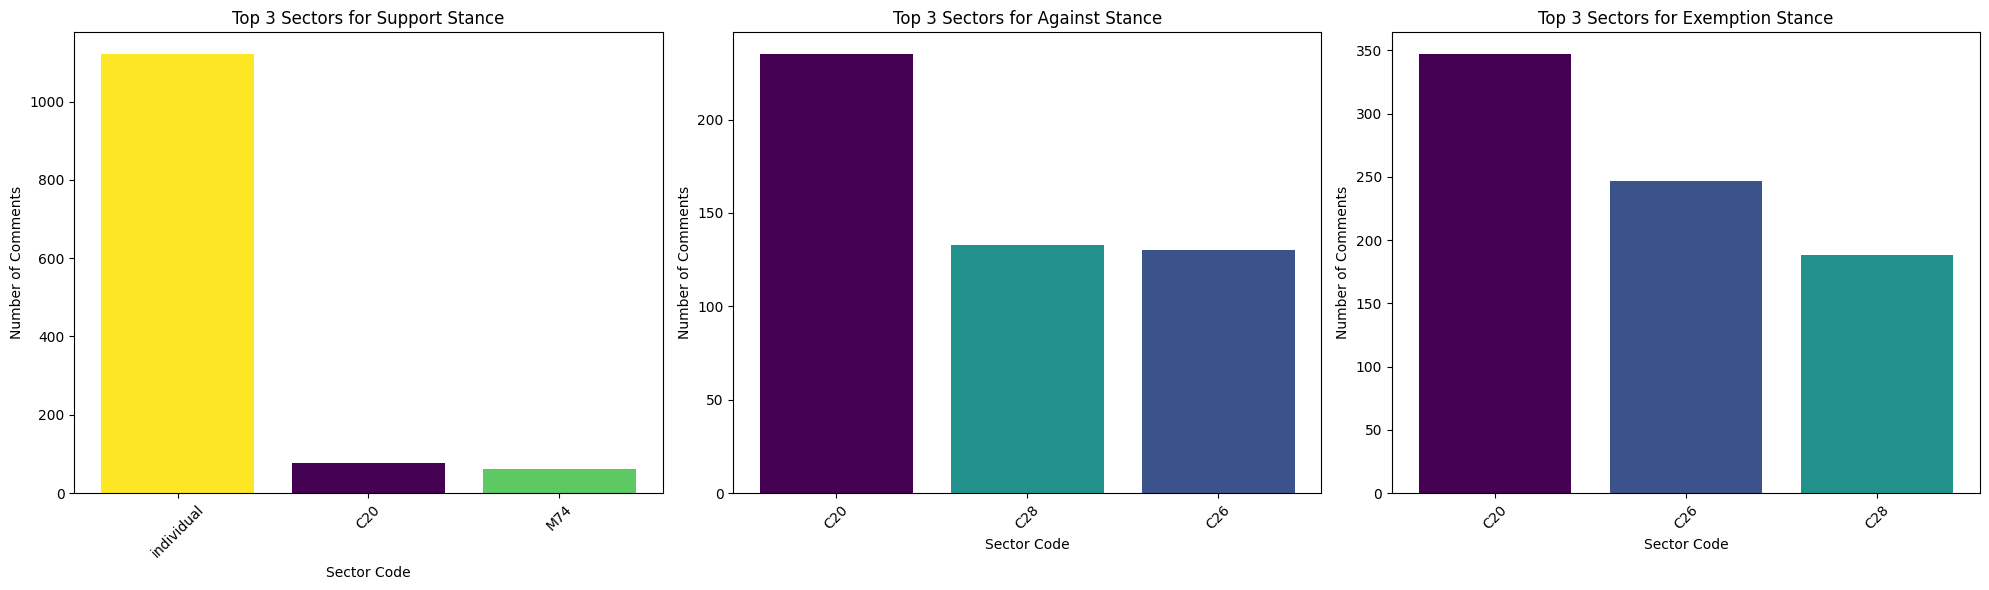


Sector Code Definitions:
C20: Manufacture of chemicals and chemical products
C26: Manufacture of computer, electronic and optical products
C28: Manufacture of machinery and equipment n.e.c.
M74: Other professional, scientific and technical activities
individual: No description available


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the mapping from sector codes to full names
sector_names = {
    'C20': 'Manufacture of chemicals and chemical products',
    'N': 'Administrative and support service activities',
    'M74': 'Other professional, scientific and technical activities',
    'C28': 'Manufacture of machinery and equipment n.e.c.',
    'C26': 'Manufacture of computer, electronic and optical products'
}

# Keep the original sector codes for the x-axis
top_sectors_support_codes = top_sectors_support.copy()
top_sectors_against_codes = top_sectors_against.copy()
top_sectors_exemption_codes = top_sectors_exemption.copy()

# Combine all unique sector codes from the top sectors across all stances
all_top_codes = list(top_sectors_support_codes.index) + list(top_sectors_against_codes.index) + list(top_sectors_exemption_codes.index)
unique_top_codes = sorted(list(set(all_top_codes)))

# Create a color map for unique sector codes
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_top_codes)))
color_map = dict(zip(unique_top_codes, colors))


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6)) # Increased figure width for longer labels

# Plot for Support Stance
ax1.bar(top_sectors_support_codes.index, top_sectors_support_codes.values, color=[color_map[code] for code in top_sectors_support_codes.index])
ax1.set_title('Top 3 Sectors for Support Stance')
ax1.set_xlabel('Sector Code')
ax1.set_ylabel('Number of Comments')
ax1.tick_params(axis='x', rotation=45) # Rotate labels for better readability


# Plot for Against Stance
ax2.bar(top_sectors_against_codes.index, top_sectors_against_codes.values, color=[color_map[code] for code in top_sectors_against_codes.index])
ax2.set_title('Top 3 Sectors for Against Stance')
ax2.set_xlabel('Sector Code')
ax2.set_ylabel('Number of Comments')
ax2.tick_params(axis='x', rotation=45) # Rotate labels for better readability


# Plot for Exemption Stance
ax3.bar(top_sectors_exemption_codes.index, top_sectors_exemption_codes.values, color=[color_map[code] for code in top_sectors_exemption_codes.index])
ax3.set_title('Top 3 Sectors for Exemption Stance')
ax3.set_xlabel('Sector Code')
ax3.set_ylabel('Number of Comments')
ax3.tick_params(axis='x', rotation=45) # Rotate labels for better readability


plt.tight_layout()
plt.show()

# Add a caption explaining the sector codes
print("\nSector Code Definitions:")
for code in unique_top_codes:
    if code in sector_names:
        print(f"{code}: {sector_names[code]}")
    else:
        print(f"{code}: No description available") # Handle cases where a code might not be in the dictionary

## Modify df prediction


In [ ]:
df_prediction.loc[df_prediction['Type'] == 'Individual', 'fine_sector'] = 'individual'
display(df_prediction.head())

,Ref.,Type,Date,Content,Org. country,Org. type,Org. name,Company name confidential,attachment_author,General Comments,...,attachments,combined_text,attachment_link_dummy,confidential_info_dummy,missing_key_info,fine_sector,bart_stance,stance_T0_5,stance_T0_7,gpt_stance
0,3843,Individual,3/22/2023 18:20,Scope or restriction option analysis,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,scope of restriction:\nthe proposed restrictio...,0,0,0,individual,uncertain,uncertain,uncertain,exemption
1,3849,BehalfOfAnOrganisation,3/23/2023 1:45,Scope or restriction option analysis,Denmark,Company,<redacted>,Yes,SUOMELA Sanna,Please refer to the further outline in the att...,...,https://www.industrydocuments.ucsf.edu/chemica...,please refer to the further outline in the att...,1,0,0,J63,uncertain,uncertain,uncertain,uncertain
2,3851,BehalfOfAnOrganisation,3/23/2023 9:57,Request for exemption,Austria,Company,<redacted>,Yes,NaN,We are using fluoropolymers for seals 3851,...,NaN,we are using fluoropolymers for seals petroleu...,0,0,0,C19,exemption,uncertain,uncertain,uncertain
3,3852,Individual,3/23/2023 10:31,Scope or restriction option analysis,NaN,NaN,NaN,NaN,NaN,The proposed ban encompasses an inconceivable ...,...,NaN,the proposed ban encompasses an inconceivable ...,0,0,0,individual,uncertain,uncertain,uncertain,against
4,3853,BehalfOfAnOrganisation,3/24/2023 10:30,Scope or restriction option analysis,Germany,Company,ESZ W. Becker GmbH,NaN,NaN,"Good morning, We are a manufacturer of elastom...",...,NaN,"good morning,\nwe are a manufacturer of elasto...",0,0,0,C22,uncertain,uncertain,uncertain,against


## Create df final


In [ ]:
df_final = df_prediction.copy()
display(df_final.head())

,Ref.,Type,Date,Content,Org. country,Org. type,Org. name,Company name confidential,attachment_author,General Comments,...,attachments,combined_text,attachment_link_dummy,confidential_info_dummy,missing_key_info,fine_sector,bart_stance,stance_T0_5,stance_T0_7,gpt_stance
0,3843,Individual,3/22/2023 18:20,Scope or restriction option analysis,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,scope of restriction:\nthe proposed restrictio...,0,0,0,individual,uncertain,uncertain,uncertain,exemption
1,3849,BehalfOfAnOrganisation,3/23/2023 1:45,Scope or restriction option analysis,Denmark,Company,<redacted>,Yes,SUOMELA Sanna,Please refer to the further outline in the att...,...,https://www.industrydocuments.ucsf.edu/chemica...,please refer to the further outline in the att...,1,0,0,J63,uncertain,uncertain,uncertain,uncertain
2,3851,BehalfOfAnOrganisation,3/23/2023 9:57,Request for exemption,Austria,Company,<redacted>,Yes,NaN,We are using fluoropolymers for seals 3851,...,NaN,we are using fluoropolymers for seals petroleu...,0,0,0,C19,exemption,uncertain,uncertain,uncertain
3,3852,Individual,3/23/2023 10:31,Scope or restriction option analysis,NaN,NaN,NaN,NaN,NaN,The proposed ban encompasses an inconceivable ...,...,NaN,the proposed ban encompasses an inconceivable ...,0,0,0,individual,uncertain,uncertain,uncertain,against
4,3853,BehalfOfAnOrganisation,3/24/2023 10:30,Scope or restriction option analysis,Germany,Company,ESZ W. Becker GmbH,NaN,NaN,"Good morning, We are a manufacturer of elastom...",...,NaN,"good morning,\nwe are a manufacturer of elasto...",0,0,0,C22,uncertain,uncertain,uncertain,against


## Filter by stance and top sectors (support)



In [ ]:
df_support_top_sectors = df_final[
    (df_final['gpt_stance'] == 'support') &
    (df_final['fine_sector'].isin(top_sectors_support.index))
].copy()
display(df_support_top_sectors.head())

,Ref.,Type,Date,Content,Org. country,Org. type,Org. name,Company name confidential,attachment_author,General Comments,...,attachments,combined_text,attachment_link_dummy,confidential_info_dummy,missing_key_info,fine_sector,bart_stance,stance_T0_5,stance_T0_7,gpt_stance
26,3879,Individual,4/10/2023 19:53,NaN,NaN,NaN,NaN,NaN,NaN,Please ban these products as quickly as possib...,...,NaN,please ban these products as quickly as possib...,0,0,0,individual,support,support,uncertain,support
58,3915,BehalfOfAnOrganisation,4/20/2023 11:11,Scope or restriction option analysis,Germany,Company,<redacted>,Yes,NaN,We appreciate the intent to drastically reduce...,...,NaN,we appreciate the intent to drastically reduce...,0,0,0,C20,uncertain,uncertain,uncertain,support
64,3921,Individual,4/20/2023 21:05,Information on benefits,NaN,NaN,NaN,NaN,NaN,I support the proposal. It is necessary. 3921,...,NaN,i support the proposal. it is necessary. use o...,0,0,0,individual,uncertain,uncertain,uncertain,support
65,3922,BehalfOfAnOrganisation,4/20/2023 21:21,Scope or restriction option analysis,Sweden,Company,Zound Industries,NaN,NaN,We support the restriction. A total ban is nec...,...,NaN,we support the restriction. a total ban is nec...,0,0,0,C20,support,support,uncertain,support
162,4024,MemberState,5/8/2023 14:37,Scope or restriction option analysis,NaN,NaN,NaN,NaN,NaN,In the annex we provide a first comment from B...,...,https://www.industrydocuments.ucsf.edu/chemica...,in the annex we provide a first comment from b...,1,0,0,C20,support,uncertain,uncertain,support


In [ ]:
df_against_top_sectors = df_final[
    (df_final['gpt_stance'] == 'against') &
    (df_final['fine_sector'].isin(top_sectors_against.index))
].copy()
display(df_against_top_sectors.head())

,Ref.,Type,Date,Content,Org. country,Org. type,Org. name,Company name confidential,attachment_author,General Comments,...,attachments,combined_text,attachment_link_dummy,confidential_info_dummy,missing_key_info,fine_sector,bart_stance,stance_T0_5,stance_T0_7,gpt_stance
12,3864,BehalfOfAnOrganisation,3/29/2023 16:30,Request for exemption,Germany,Company,Leistritz Pumpen GmbH,NaN,NaN,NaN,...,NaN,pfas are high technologie polymeres which are ...,0,0,0,C20,uncertain,uncertain,uncertain,against
27,3881,BehalfOfAnOrganisation,4/11/2023 12:33,Information on benefits,Netherlands,Company,Fluortubing,NaN,NaN,SEMICON APPLICATIONS FLUORTUBING TUBES Fluort...,...,NaN,semicon applications fluortubing tubes\n\nfluo...,0,0,0,C28,uncertain,uncertain,uncertain,against
32,3887,BehalfOfAnOrganisation,4/12/2023 19:19,Scope or restriction option analysis,Ireland,Company,<redacted>,Yes,NaN,NaN,...,NaN,general comments:\na complete list of uses and...,0,1,0,C20,support,uncertain,uncertain,against
43,3899,BehalfOfAnOrganisation,4/17/2023 18:47,Hazard or exposure,Italy,Company,<redacted>,Yes,NaN,"Dear Sirs, we are a Company that produce PTFE ...",...,NaN,"dear sirs, we are a company that produce ptfe ...",0,0,0,C20,uncertain,uncertain,uncertain,against
50,3907,BehalfOfAnOrganisation,4/18/2023 13:44,Scope or restriction option analysis,United Kingdom,Company,Corrosion Resistant Products Ltd,NaN,NaN,"Please refer to attached document ""Section III...",...,https://www.industrydocuments.ucsf.edu/chemica...,"please refer to attached document ""section iii...",1,0,0,C20,support,uncertain,uncertain,against


In [ ]:
df_exemption_top_sectors = df_final[
    (df_final['gpt_stance'] == 'exemption') &
    (df_final['fine_sector'].isin(top_sectors_exemption.index))
].copy()
display(df_exemption_top_sectors.head())

,Ref.,Type,Date,Content,Org. country,Org. type,Org. name,Company name confidential,attachment_author,General Comments,...,attachments,combined_text,attachment_link_dummy,confidential_info_dummy,missing_key_info,fine_sector,bart_stance,stance_T0_5,stance_T0_7,gpt_stance
9,3860,BehalfOfAnOrganisation,3/28/2023 14:40,Information on benefits,United Kingdom,Company,<redacted>,Yes,NaN,Sphere Fluidics is an interested party in the ...,...,NaN,sphere fluidics is an interested party in the ...,0,0,0,C20,uncertain,uncertain,uncertain,exemption
10,3861,BehalfOfAnOrganisation,3/29/2023 7:30,Request for exemption,"Korea, Republic of",Company,<redacted>,Yes,NaN,It is desirable to be recognized as an 'exempt...,...,NaN,it is desirable to be recognized as an 'exempt...,0,0,0,C20,exemption,uncertain,uncertain,exemption
14,3866,BehalfOfAnOrganisation,3/29/2023 17:20,Scope or restriction option analysis,Finland,Company,Atolli OY,NaN,christian.sundberg,Potential impact on fluoropolymer semifinished...,...,https://www.industrydocuments.ucsf.edu/chemica...,potential impact on fluoropolymer semifinished...,1,0,0,C20,uncertain,uncertain,uncertain,exemption
21,3873,BehalfOfAnOrganisation,4/5/2023 11:56,Request for exemption,Italy,Company,CAAST S.p.A.,NaN,NaN,In light of the fact that 90% of the materials...,...,NaN,in light of the fact that 90% of the materials...,0,0,0,C20,exemption,uncertain,uncertain,exemption
36,3892,BehalfOfAnOrganisation,4/14/2023 10:58,NaN,China,Company,<redacted>,Yes,NaN,NaN,...,NaN,fluorochemical is not alternative to many area...,0,0,0,C20,exemption,uncertain,uncertain,exemption


In [3]:
import pandas as pd

df_final = pd.read_csv('df_final.csv')
display(df_final.head())

,Ref.,Type,Date,Content,Org. country,Org. type,Org. name,Company name confidential,attachment_author,General Comments,...,attachments,combined_text,attachment_link_dummy,confidential_info_dummy,missing_key_info,fine_sector,bart_stance,stance_T0_5,stance_T0_7,gpt_stance
0,3843,Individual,3/22/2023 18:20,Scope or restriction option analysis,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,scope of restriction:\nthe proposed restrictio...,0,0,0,individual,uncertain,uncertain,uncertain,exemption
1,3849,BehalfOfAnOrganisation,3/23/2023 1:45,Scope or restriction option analysis,Denmark,Company,<redacted>,Yes,SUOMELA Sanna,Please refer to the further outline in the att...,...,https://www.industrydocuments.ucsf.edu/chemica...,please refer to the further outline in the att...,1,0,0,J63,uncertain,uncertain,uncertain,uncertain
2,3851,BehalfOfAnOrganisation,3/23/2023 9:57,Request for exemption,Austria,Company,<redacted>,Yes,NaN,We are using fluoropolymers for seals 3851,...,NaN,we are using fluoropolymers for seals petroleu...,0,0,0,C19,exemption,uncertain,uncertain,uncertain
3,3852,Individual,3/23/2023 10:31,Scope or restriction option analysis,NaN,NaN,NaN,NaN,NaN,The proposed ban encompasses an inconceivable ...,...,NaN,the proposed ban encompasses an inconceivable ...,0,0,0,individual,uncertain,uncertain,uncertain,against
4,3853,BehalfOfAnOrganisation,3/24/2023 10:30,Scope or restriction option analysis,Germany,Company,ESZ W. Becker GmbH,NaN,NaN,"Good morning, We are a manufacturer of elastom...",...,NaN,"good morning,\nwe are a manufacturer of elasto...",0,0,0,C22,uncertain,uncertain,uncertain,against


In [6]:
sector_counts_per_stance = df_final.groupby('gpt_stance')['fine_sector'].nunique()
print("Number of unique sectors within each stance:")
display(sector_counts_per_stance)

Number of unique sectors within each stance:


,fine_sector
gpt_stance,
against,46
exemption,56
support,40
uncertain,60


# NACE code decription matching

In [14]:
df_nace = pd.read_csv('nace_codes.csv')
display(df_nace.head())

,NACE_Code,Description
0,A,"Agriculture, forestry and fishing"
1,A1,"Crop and animal production, hunting and relate..."
2,A1.1,Growing of non-perennial crops
3,A1.1.1,"Growing of cereals (except rice), leguminous c..."
4,A1.1.2,Growing of rice


In [15]:
# Rename the NACE code column to match the fine_sector column for merging
df_nace_renamed = df_nace.rename(columns={'NACE_Code': 'fine_sector'})

# Merge the sectors_by_stance DataFrame with the NACE code DataFrame
sectors_with_description = pd.merge(sectors_by_stance, df_nace_renamed[['fine_sector', 'Description']], on='fine_sector', how='left')

# Save the updated DataFrame to a new CSV file
sectors_with_description.to_csv('sectors_by_stance_with_description.csv', index=False)

print("Saved sectors by stance with descriptions to 'sectors_by_stance_with_description.csv'")
display(sectors_with_description.head())

Saved sectors by stance with descriptions to 'sectors_by_stance_with_description.csv'


,gpt_stance,fine_sector,count,Description
0,against,C20,235,Manufacture of chemicals and chemical products
1,against,C28,133,Manufacture of machinery and equipment n.e.c.
2,against,C26,130,"Manufacture of computer, electronic and optica..."
3,against,C22,107,Manufacture of rubber and plastic products
4,against,individual,71,NaN
